In [1]:
#from counterfactual_fraud_model.pipeline import OffPolicyEvaluationPipeline
from simulation_analysis import *

In [ ]:
# TODO: ADD REAL METRIC VALUE TO OPE CHART
exploration_rates = np.linspace(0.01, 0.2, 4)
random_state = 667

# Run simulations
results, reference_data = run_simulations(exploration_rates, random_state=random_state, cutoff=0.1)

Running 4 simulations...
Running simulation 1/4 with exploration_rate=0.010
Running simulation 2/4 with exploration_rate=0.073
Running simulation 3/4 with exploration_rate=0.137
Running simulation 4/4 with exploration_rate=0.200


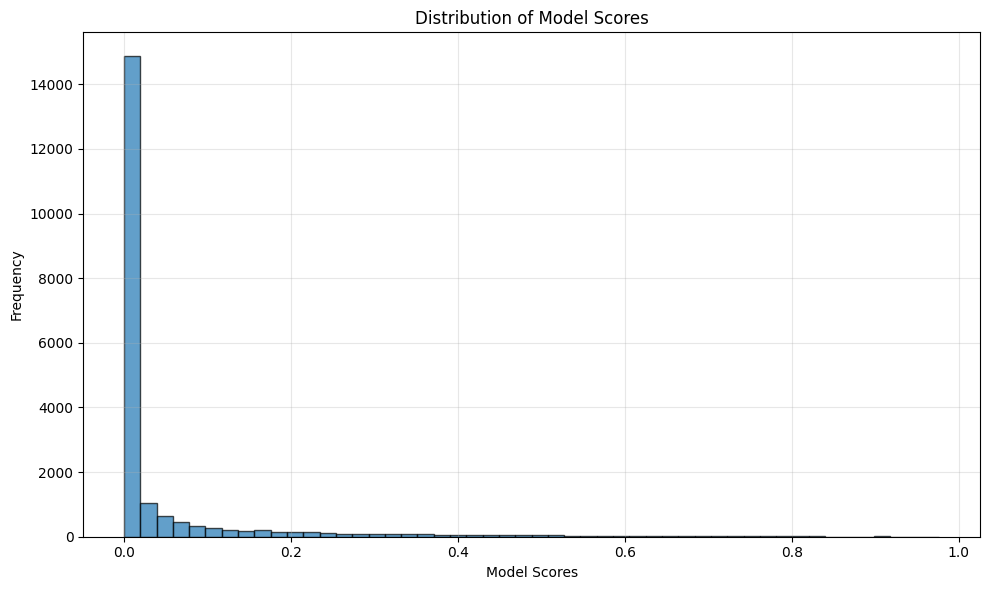

In [3]:
plot_model_scores_histogram(reference_data)

In [4]:
pipeline_params = results[0]['parameters']
summary_table = create_data_summary_table(reference_data, pipeline_params)
summary_table

,Metric,Value
0,Total Transactions,20000
1,True Fraud Rate,0.0544
2,Alpha,0.1
3,Beta,2.0
4,Mean,-0.5
5,SD,0.5
6,Sample Size,20000


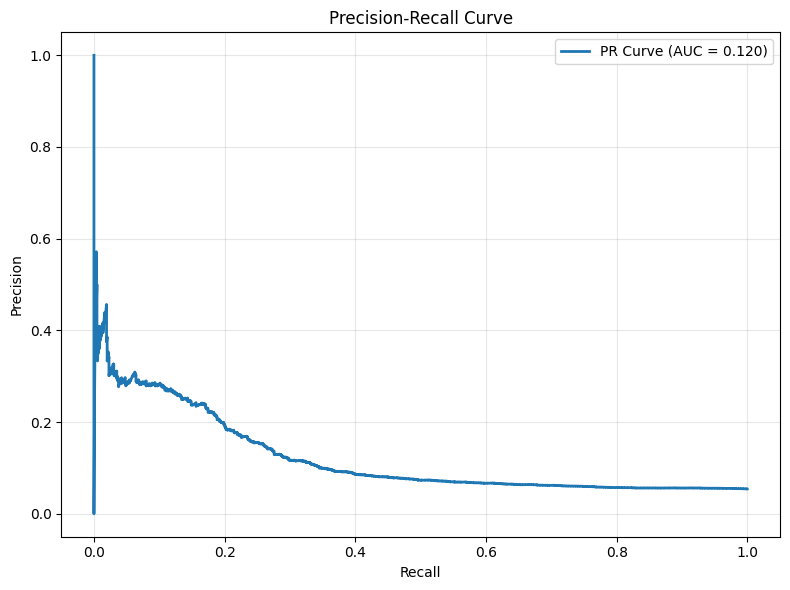

In [5]:
plot_precision_recall_curve(reference_data)

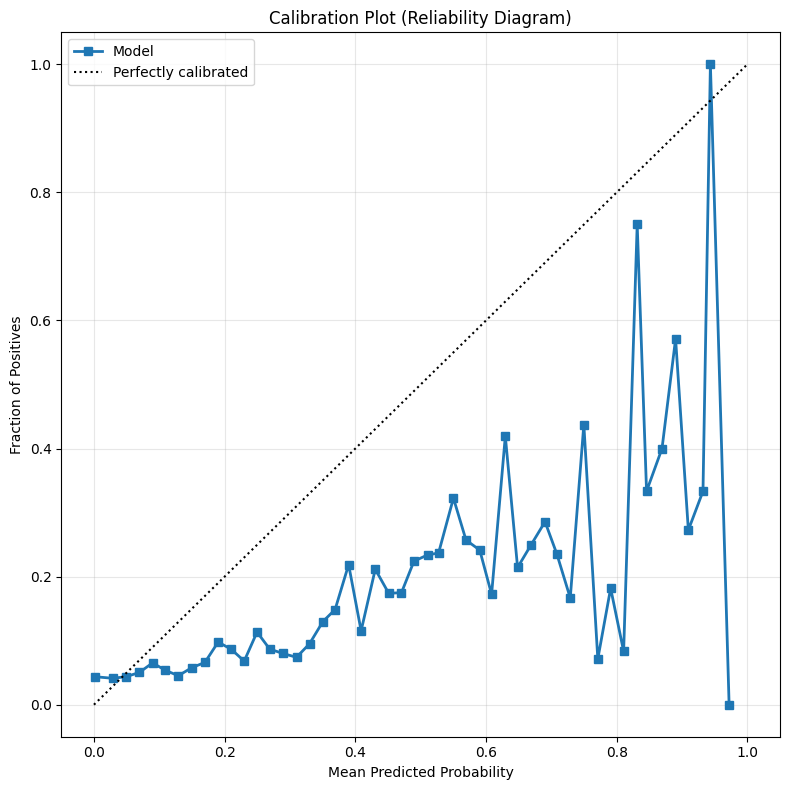

In [6]:
plot_calibration_curve(reference_data)

In [7]:
policy_table = create_policy_metrics_table(results)
policy_table

,exploration_rate,allow_rate,block_rate,fraud_rate_overall,fraud_rate_allowed,total_transactions,allowed_transactions,blocked_transactions
0,0.010000,0.86995,0.13005,0.0544,0.044198,20000,17399,2601
1,0.073333,0.87740,0.12260,0.0544,0.045019,20000,17548,2452
2,0.136667,0.88660,0.11340,0.0544,0.046244,20000,17732,2268
3,0.200000,0.89460,0.10540,0.0544,0.046948,20000,17892,2108


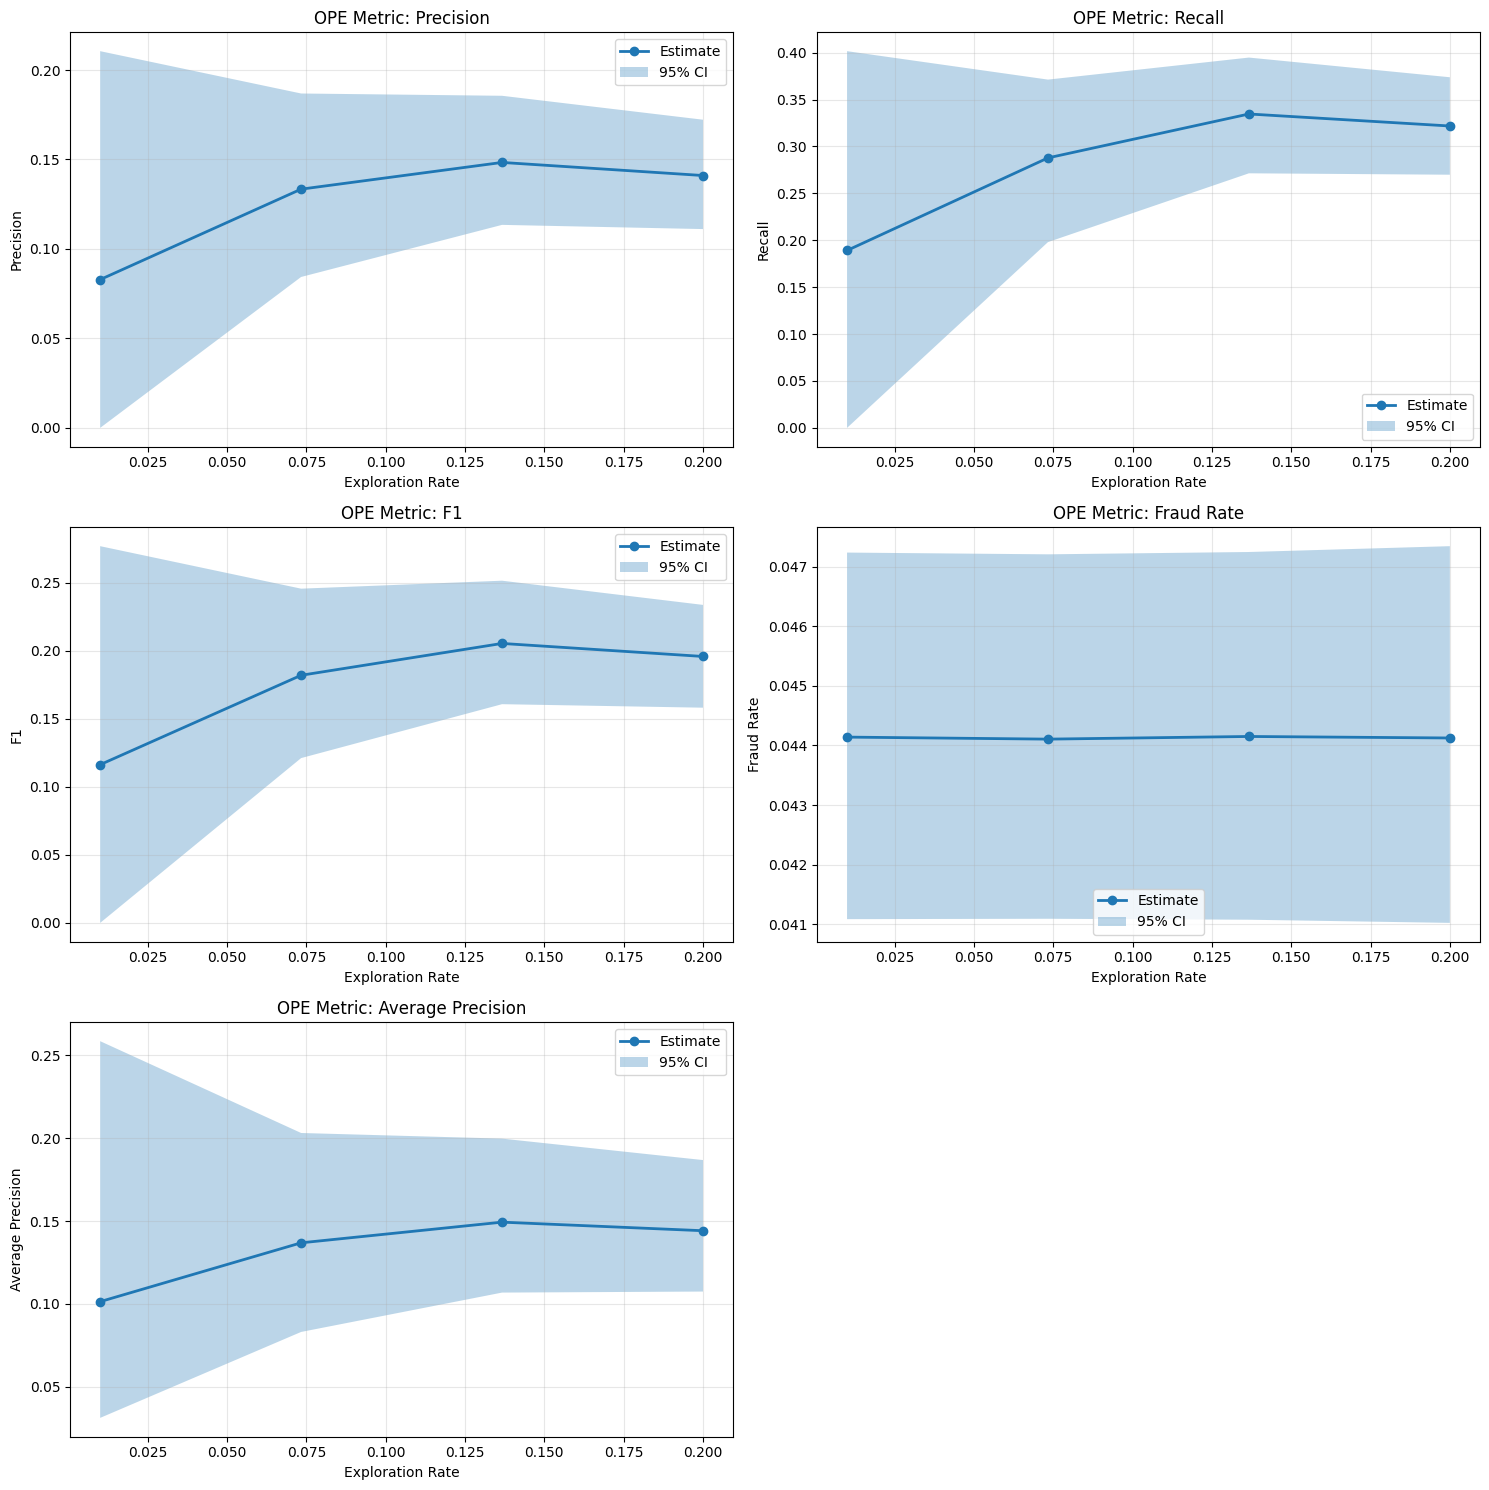

In [8]:
plot_ope_metrics(results)

In [9]:
from synthetic_simulation_analysis import *

Starting Synthetic Multi-Parameter Simulation Analysis

Exploration Rate Analysis with lightgbm model
Running 3 simulations with lightgbm model...
Running simulation 1/3 with exploration_rate=0.010
Running simulation 2/3 with exploration_rate=0.055
Running simulation 3/3 with exploration_rate=0.100

Generating visualizations and tables...
1. Generating model scores histogram...


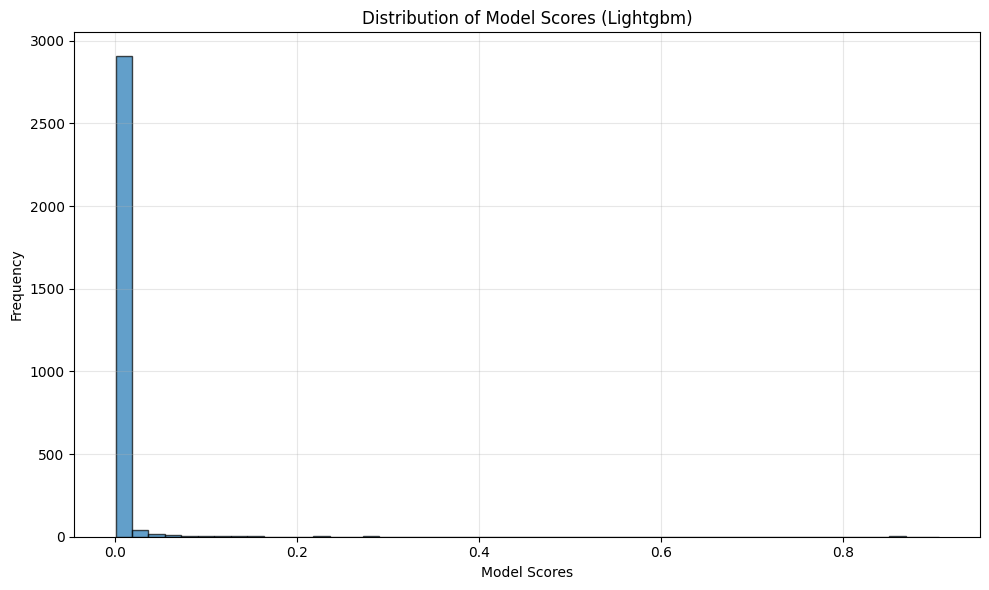

2. Creating data summary table...

Synthetic Data Summary Table:
            Metric              Value
Total Transactions               3000
   True Fraud Rate             0.0200
         N Samples              10000
        N Features                 30
     N Informative                 15
       N Redundant                  5
        Model Type ModelType.LIGHTGBM
         Test Size                0.3
         Class Sep                1.0

3. Generating calibration plot...


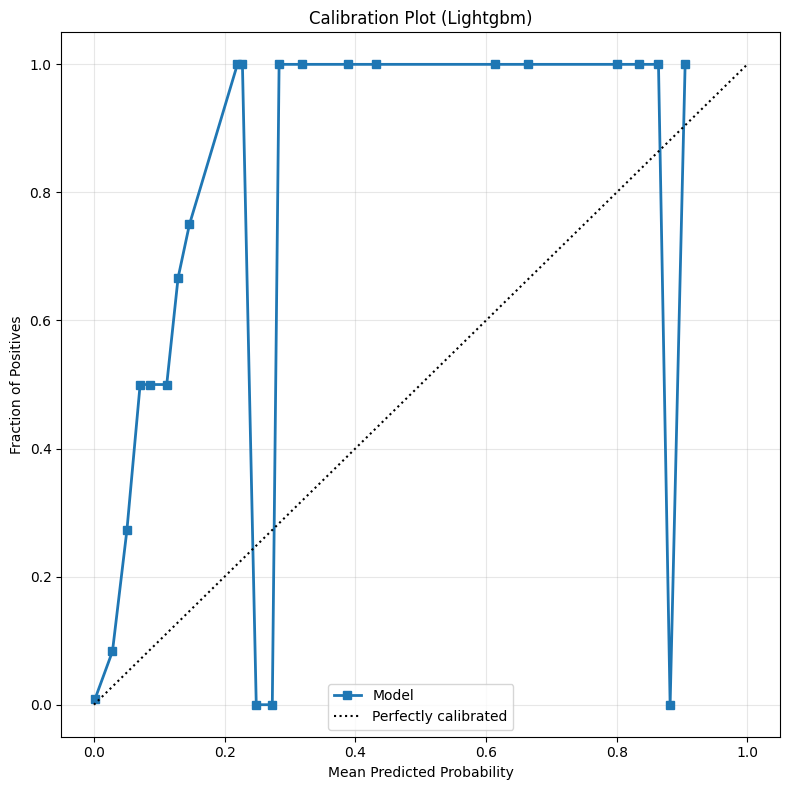

4. Generating precision-recall curve...


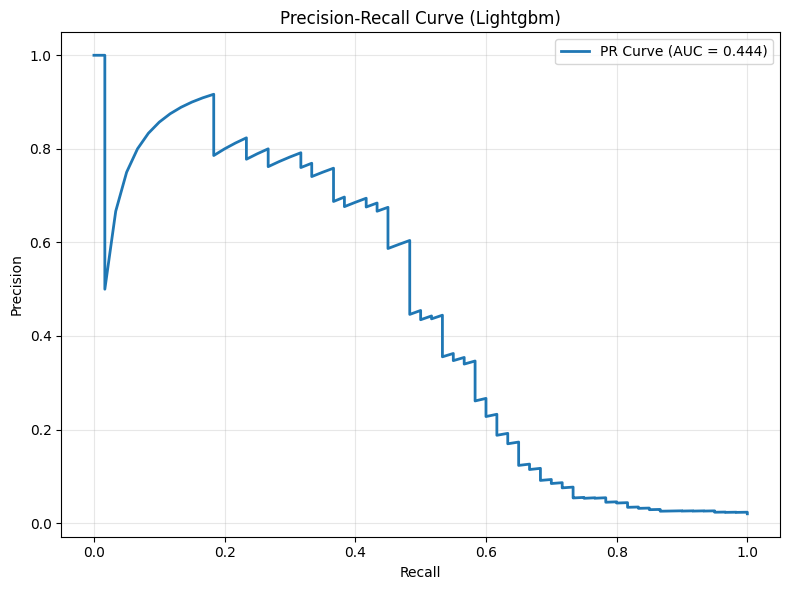

5. Creating policy metrics table...

Policy Metrics Table:
 exploration_rate  allow_rate  block_rate  fraud_rate_overall  fraud_rate_allowed  total_transactions  allowed_transactions  blocked_transactions  model_roc_auc  model_precision  model_recall  model_f1
            0.010       0.985       0.015                0.02              0.0112                3000                  2955                    45         0.8318            0.875        0.1167    0.2059
            0.055       0.986       0.014                0.02              0.0118                3000                  2958                    42         0.8318            0.875        0.1167    0.2059
            0.100       0.987       0.013                0.02              0.0125                3000                  2961                    39         0.8318            0.875        0.1167    0.2059

6. Generating OPE metrics plots...


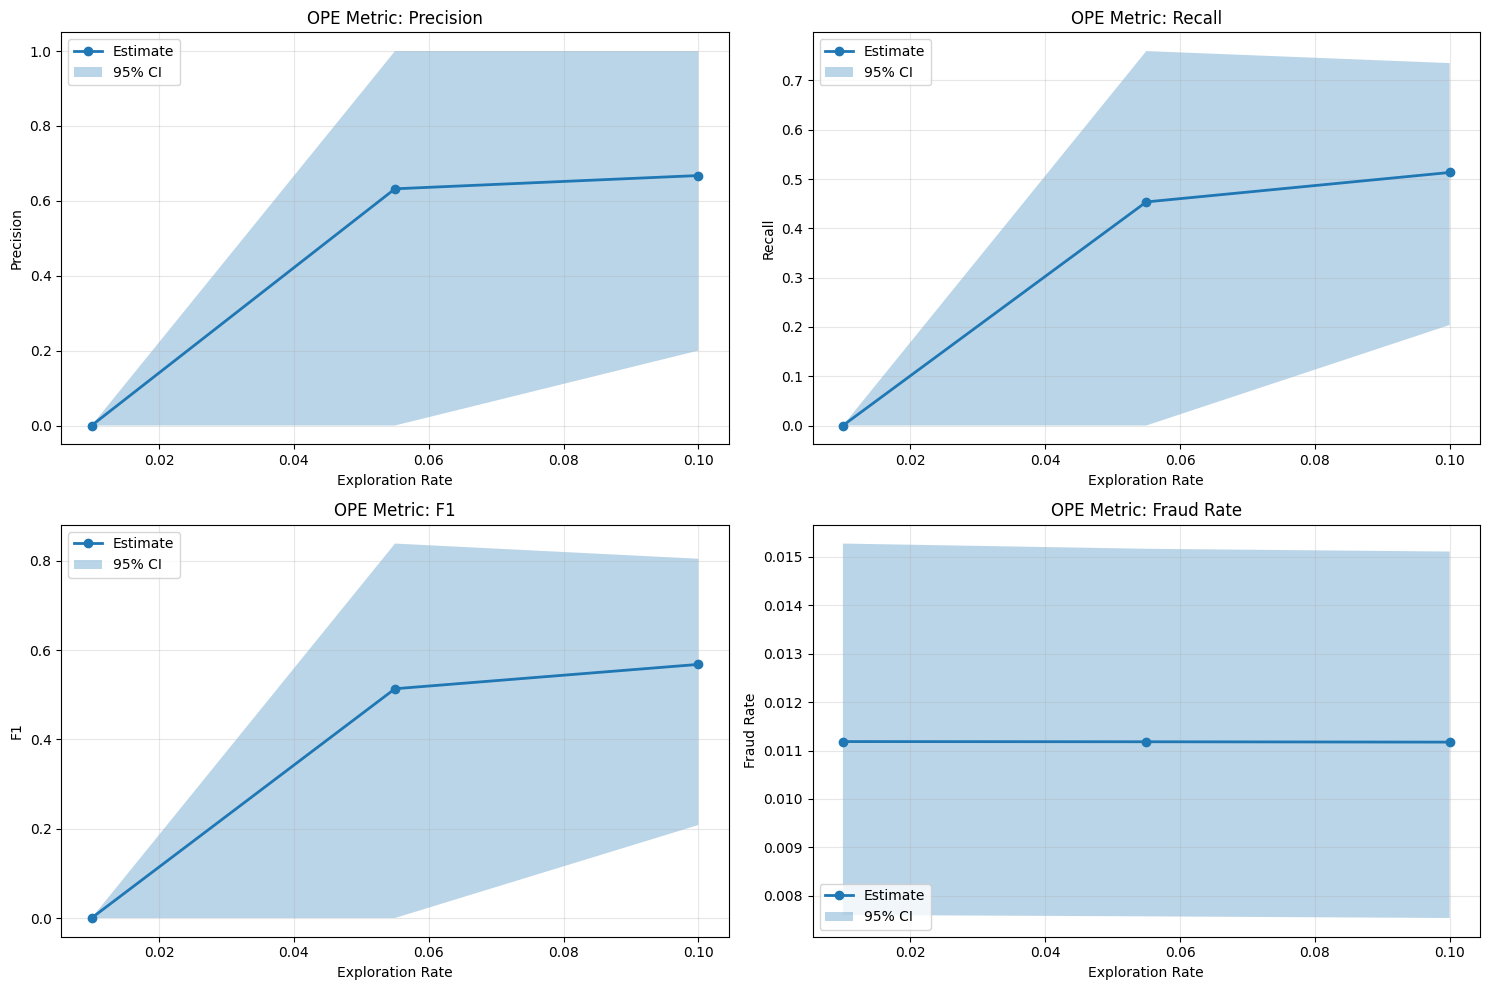


Model Comparison Analysis
Running model comparison with 2 models...
Running simulation 1/2 with lightgbm model...
Running simulation 2/2 with random_forest model...

Generating visualizations and tables...
1. Generating model scores comparison...


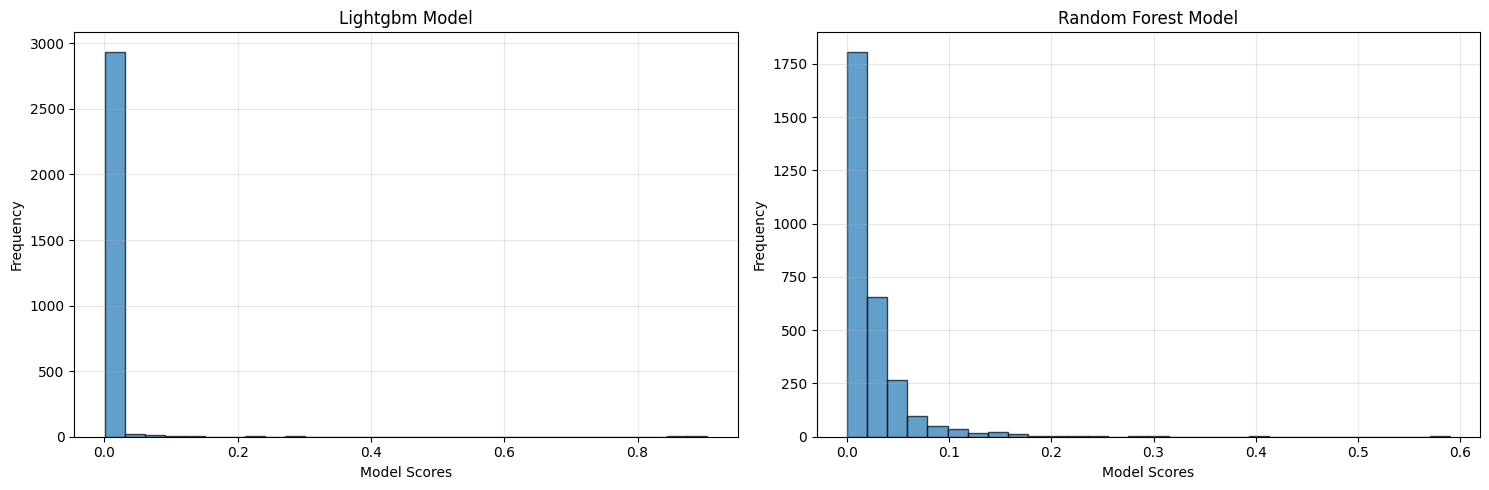

2. Creating model comparison table...

Model Comparison Table:
   model_type  allow_rate  block_rate  fraud_rate_overall  fraud_rate_allowed  total_transactions  allowed_transactions  blocked_transactions  model_roc_auc  model_precision  model_recall  model_f1
     lightgbm       0.986       0.014                0.02              0.0118                3000                  2958                    42         0.8318            0.875        0.1167    0.2059
random_forest       0.915       0.085                0.02              0.0117                3000                  2745                   255         0.7960            1.000        0.0333    0.0645

3. Generating model performance comparison...


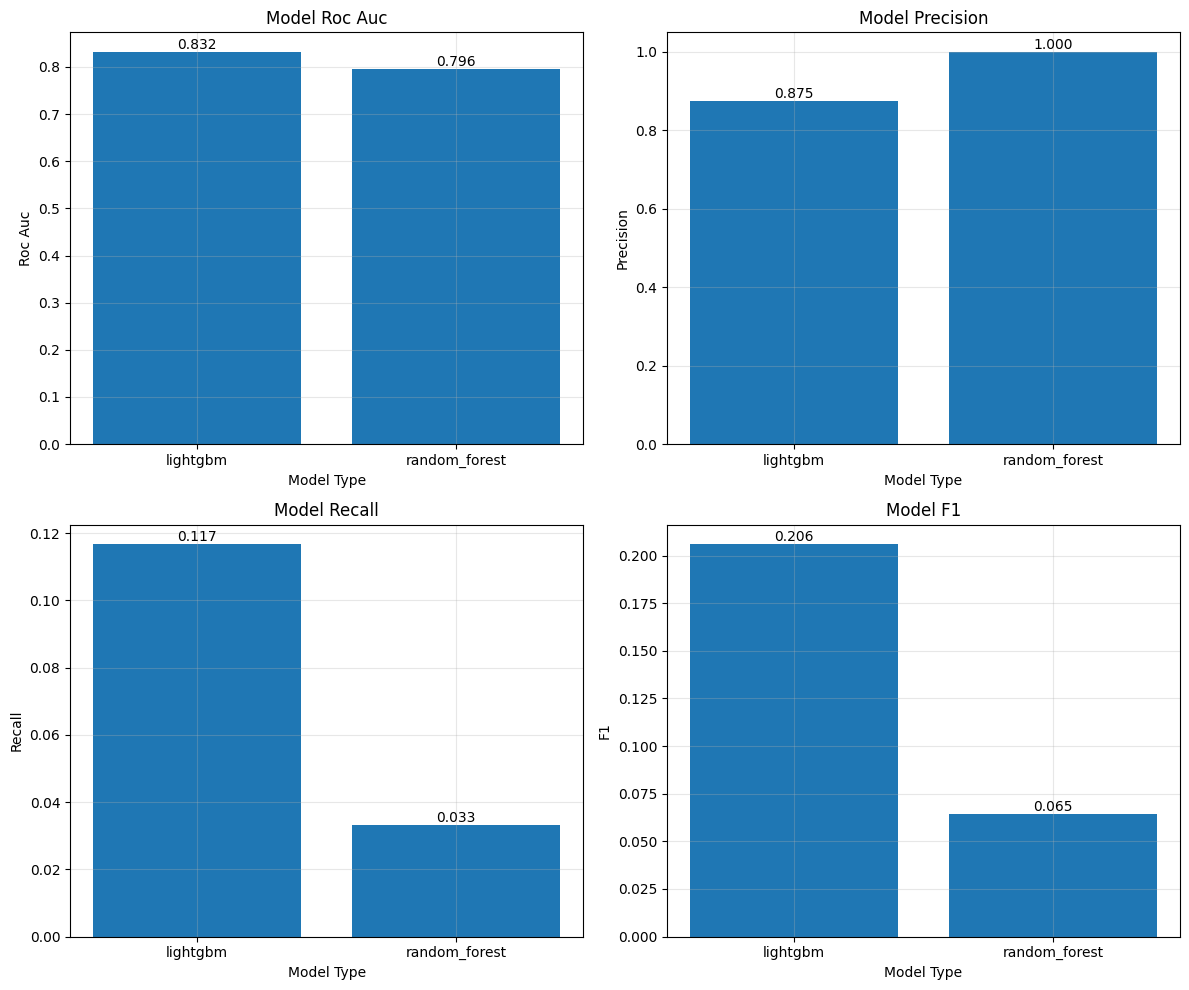

4. Generating calibration plots for each model...


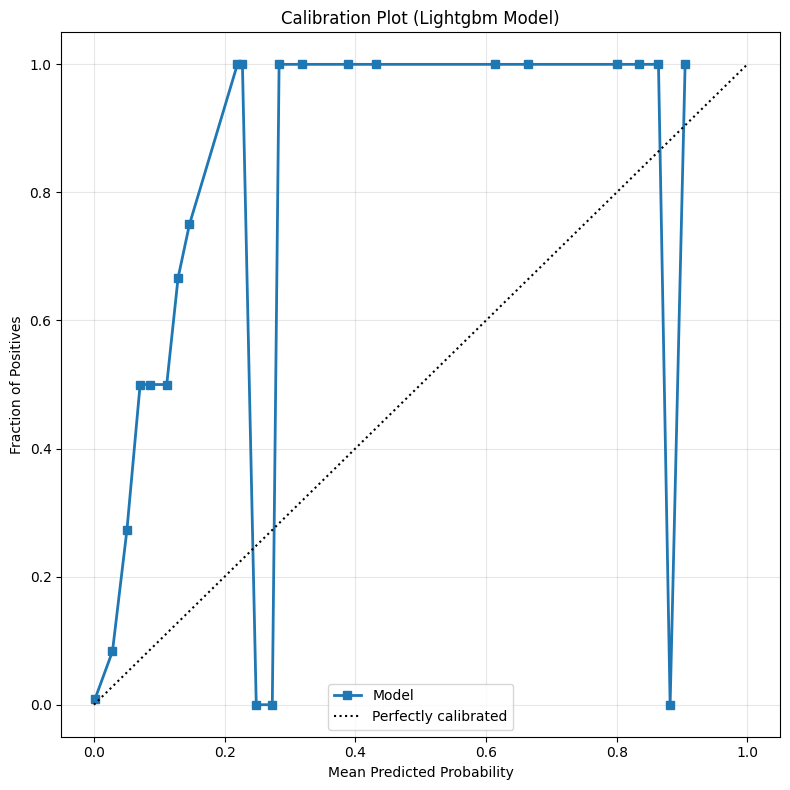

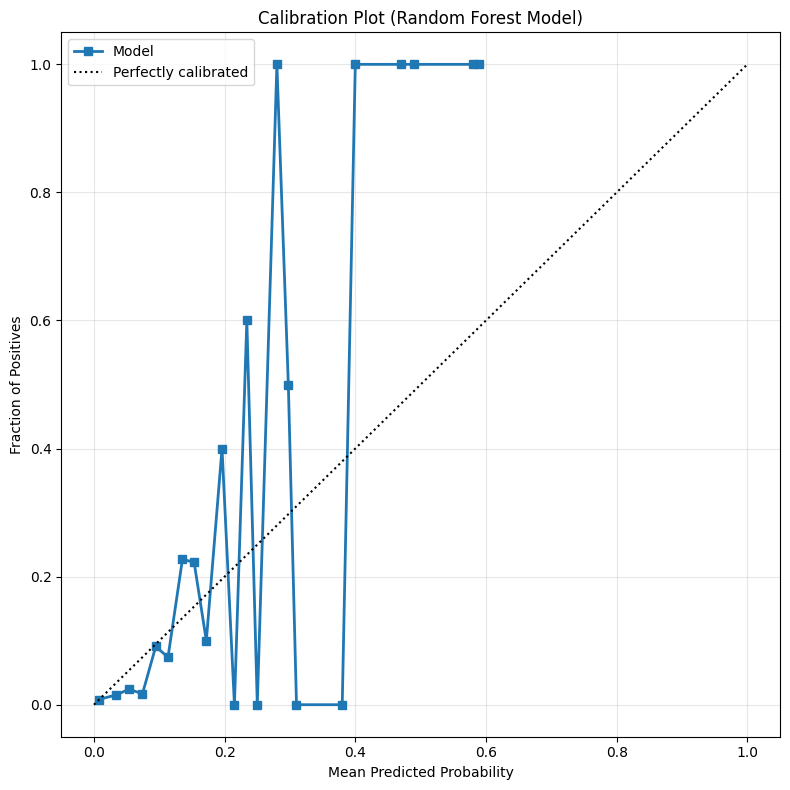

5. Generating precision-recall curves for each model...


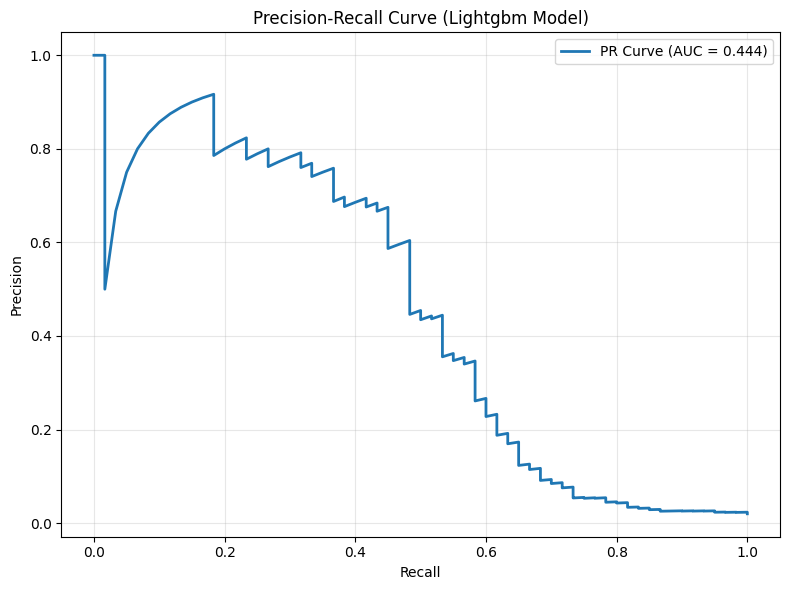

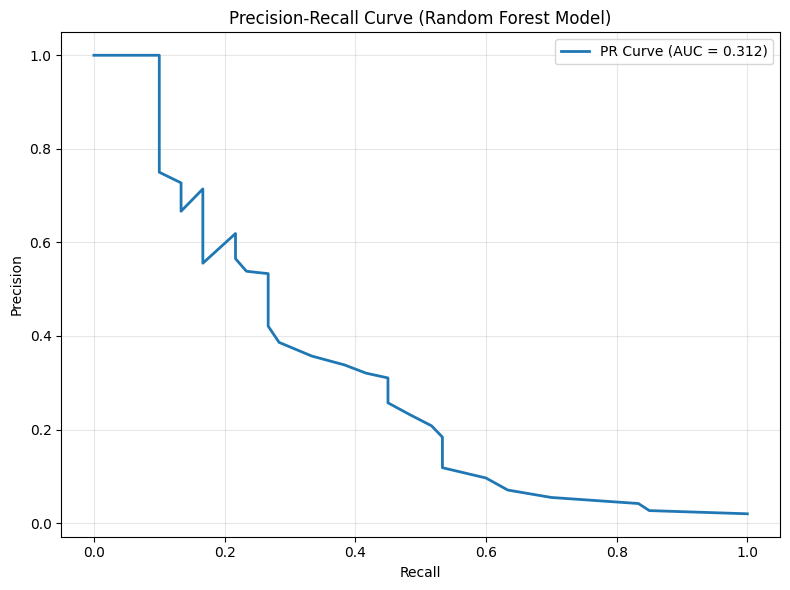


All analyses complete!


In [10]:
print("Starting Synthetic Multi-Parameter Simulation Analysis")
print("=" * 60)

# Configuration for exploration rate analysis
exploration_rates = np.linspace(0.01, 0.1, 3)

# Configuration for model comparison
model_types = ["lightgbm", "random_forest"]

# Run exploration rate analysis with LightGBM
run_exploration_rate_analysis(exploration_rates, model_type="lightgbm")

# Run model comparison analysis
run_model_comparison_analysis(model_types)

print("\nAll analyses complete!")
print("=" * 60)

In [ ]:
from counterfactual_fraud_model import SyntheticRetrainingPipeline

def test_retraining_pipeline():
    """Test the basic functionality of SyntheticRetrainingPipeline."""
    print("Testing SyntheticRetrainingPipeline...")
    print("=" * 50)
    
    # Create pipeline with small dataset for quick testing
    pipeline = SyntheticRetrainingPipeline(
        n_samples=100_000,  # Small dataset for quick testing
        n_features=10,
        n_informative=5,
        random_state=42,
        retrain_model_type="lightgbm",  # Use random forest to avoid LightGBM dependency issues
        classification_threshold=0.1,
        test_size=0.5,
        retrain_test_size=0.5,
    )
    
    print("Pipeline created successfully!")
    print(f"Parameters: {pipeline.get_params()}")
    print()
    
    # Run the pipeline
    print("Running pipeline...")
    results = pipeline.run_pipeline(
        cutoff=0.2,
        exploration_rate=0.1,
        include_data=False  # Don't include data to keep output manageable
    )
    
    print("Pipeline completed successfully!")
    print()
    
    # Print key results
    print("Results Summary:")
    print("-" * 30)
    
    stats = results['statistics']
    print(f"Total transactions: {stats['total_transactions']}")
    print(f"Total allowed for retraining: {stats['total_allowed_for_retraining']}")
    print(f"Original approval rate: {stats['original_approval_rate']:.3f}")
    print(f"Original fraud rate: {stats['original_fraud_rate']:.3f}")
    print(f"New model block rate: {stats['new_model_block_rate']:.3f}")
    print(f"New model fraud rate: {stats['new_model_fraud_rate']:.3f}")
    print()
    
    print("Original Model Performance:")
    original_perf = results['original_model_performance']
    for metric, value in original_perf.items():
        print(f"  {metric}: {value:.3f}")
    print()
    
    print("Retrained Model Performance:")
    retrained_perf = results['retrained_model_performance']
    for metric, value in retrained_perf.items():
        print(f"  {metric}: {value:.3f}")
    print()
    
    print("OPE Metrics (Counterfactual Estimation):")
    ope_metrics = results['ope_metrics']
    for metric_name, metric_stats in ope_metrics.items():
        print(f"  {metric_name}: {metric_stats['mean']:.3f} "
              f"[{metric_stats['p025']:.3f}, {metric_stats['p975']:.3f}]")
    print()
    
    print("Dataset Info Comparison:")
    original_info = results['original_dataset_info']
    retrained_info = results['retrained_dataset_info']
    print(f"  Original dataset size: {original_info['total_samples']}")
    print(f"  Retrained dataset size: {retrained_info['n_samples']}")
    print(f"  Original fraud rate: {original_info['fraud_rate']:.3f}")
    print(f"  Retrained fraud rate: {retrained_info['fraud_rate']:.3f}")
    
    print("\nTest completed successfully! ✓")


if __name__ == "__main__":
    test_retraining_pipeline() 

ModuleNotFoundError: No module named 'src.counterfactual_fraud_model.data_generator'